In [16]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram,linkage

In [17]:
def fetchindicator(code,year="2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response=requests.get(url).json()
    data={}
    for item in response:
        country=item['country']['value']
        value=item['value']
        if value is not None:
            data[country]=value
    return pd.Series(data,name=code)


In [18]:
gdp=fetch_indicator("NY.GDP.PCAP.CD")
pop=fetch_indicator("SP.POP.TOTL")
life=fetch_indicator("SP.DYN.LE00.IN")
lit=fetch_indicator("SE.ADT.LITR.ZS")

In [19]:
df=pd.concat([gdp,pop,life,lit],axis=1)
df.columns=["GDP","Population","LifeExpectancy","Literacy"]
df.dropna(inplace=True)

In [20]:
df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [21]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [28]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)


In [29]:
plt.figure()
plt.show()

<Figure size 640x480 with 0 Axes>

k	wcss
1 	 336.00000000000006
2 	 206.43717192603808
3 	 142.06028324967596
4 	 122.46400641421171
5 	 68.71234707726028
6 	 56.092718405819106
7 	 51.08265517326418
8 	 41.70851027024395
9 	 31.213863029560223
10 	 27.04725098650771


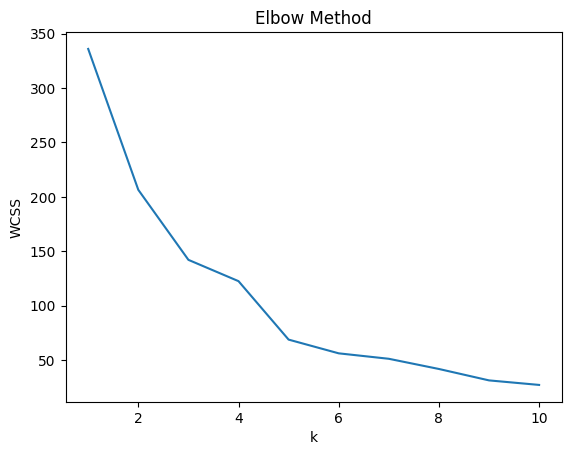

In [26]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)
wcss=[]
for k in range(1,11):
  km=KMeans(n_clusters=k,random_state=0)
  km.fit(x_scaled)
  wcss.append(km.inertia_)
print("k\twcss")
for i in range(1,11):
  print(i,"\t",wcss[i-1])

plt.plot(range(1,11),wcss)
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

##Clustering Algorithms

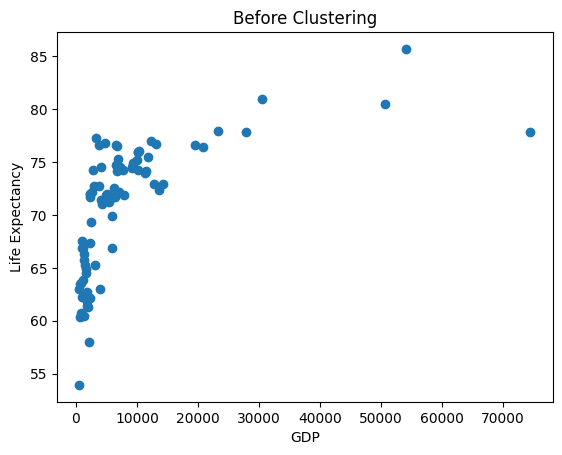

In [34]:
plt.scatter(df["GDP"],df["LifeExpectancy"])
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Before Clustering")
plt.show()


In [35]:
kmeans=KMeans(n_clusters=3,random_state=0)
labels_kmeans=kmeans.fit_predict(x_scaled)
df["KMeansCluster"]=labels_kmeans

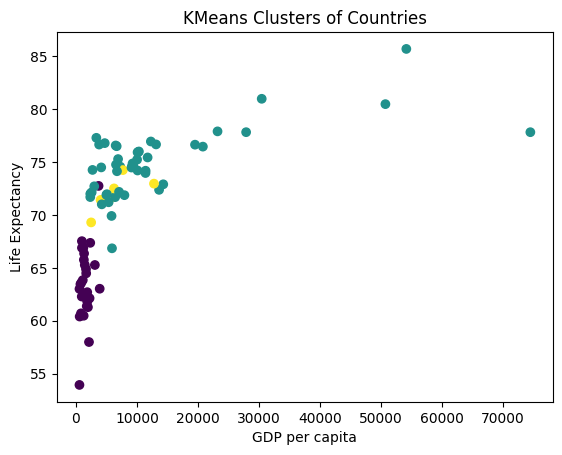

In [38]:
plt.scatter(df["GDP"],df["LifeExpectancy"],c=labels_kmeans)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("KMeans Clusters of Countries")
plt.show()

In [41]:
hc=AgglomerativeClustering(n_clusters=3)
labels_hc=hc.fit_predict(x_scaled)
df["HierarchialCluster"]=labels_hc

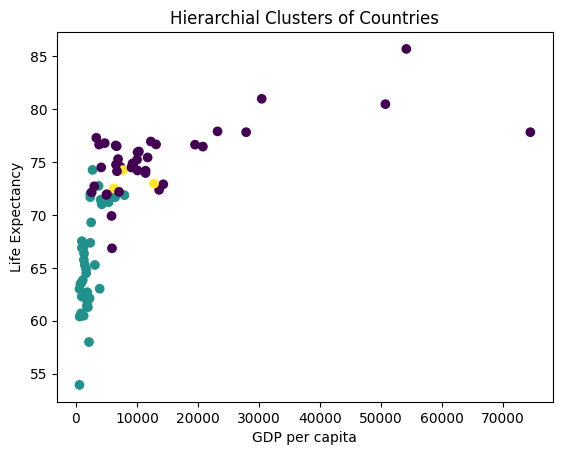

In [42]:
plt.scatter(df["GDP"],df["LifeExpectancy"],c=labels_hc)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchial Clusters of Countries")
plt.show()

In [46]:
cluster_summary=df.groupby("KMeansCluster")[["GDP","Population","LifeExpectancy","Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1601.971896  4.854521e+08       63.478867  66.779721
1              12288.225626  4.669122e+08       74.753258  92.910908
2               6437.349751  5.501554e+09       71.975830  84.851687


In [50]:
country_name = "India"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["Literacy"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: India
GDP per capita : 2347.44829434623
Population : 1425423212.0
Life Expectancy : 71.698
Literacy Rate : 76.3199996948242
KMeans Cluster : 1.0
Hierarchial Cluster : 1.0


In [55]:
country_name = "North America"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["Literacy"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: North America
GDP per capita : 74535.6365392629
Population : 373018004.0
Life Expectancy : 77.8327679594239
Literacy Rate : 98.7891464233398
KMeans Cluster : 1.0
Hierarchial Cluster : 0.0


In [54]:
country_name = "Brazil"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["Literacy"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: Brazil
GDP per capita : 9281.33282136864
Population : 210306415.0
Life Expectancy : 74.872
Literacy Rate : 94.3853874531348
KMeans Cluster : 1.0
Hierarchial Cluster : 0.0


In [59]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["Literacy"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: Viet Nam
GDP per capita : 4147.69777213621
Population : 99680655.0
Life Expectancy : 74.502
Literacy Rate : 96.129997253418
KMeans Cluster : 1.0
Hierarchial Cluster : 0.0


In [57]:
country_name = "Bahrain"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["Literacy"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: Bahrain
GDP per capita : 30470.5219276023
Population : 1524693.0
Life Expectancy : 80.992
Literacy Rate : 97.870002746582
KMeans Cluster : 1.0
Hierarchial Cluster : 0.0
